In [13]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC


In [14]:
# Import required libraries for refactored model training logic
import sys
import os
sys.path.append(os.path.abspath(".."))
from sklearn.metrics import ConfusionMatrixDisplay
from src.load_data import load_diabetes_data

In [15]:
# Load dataset
df = load_diabetes_data("/Users/danaitgebremedhin/Desktop/CSB320/Diabetes_Classification_Experiment/data/diabetes.csv")

# Display first few rows
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,5.897302,147.454335,70.914812,34.349127,1.883577,34.412522,0.648393,50.261729,1
1,1.101072,87.228809,67.057626,29.457914,0.000000,26.784201,0.356130,29.834140,0
2,7.939244,185.083876,66.054168,0.000000,0.000000,24.061055,0.663302,32.651592,1
3,0.855559,87.846161,66.187249,23.242126,89.726267,28.974094,0.176398,21.481908,0
4,0.000000,137.715755,39.183696,35.726182,177.446938,43.328373,2.335509,33.927286,1


In [16]:
from src.preprocess import preprocess_data

# Train data
X_train, X_test, y_train, y_test = preprocess_data(df)

In [17]:
from src.models import train_logistic_regression
from src.pipeline import MLModelPipeline

model = train_logistic_regression(X_train, y_train)
pipeline = MLModelPipeline(model)


train_logistic_regression executed in 0.00 seconds


In [18]:
from src.evaluate import evaluate_model

# Evaluate data
accuracy, report = evaluate_model(model, X_test, y_test)
print("Accuracy:", accuracy)
print(report)

Accuracy: 0.7402597402597403
              precision    recall  f1-score   support

           0       0.80      0.79      0.80        99
           1       0.63      0.65      0.64        55

    accuracy                           0.74       154
   macro avg       0.72      0.72      0.72       154
weighted avg       0.74      0.74      0.74       154



In [19]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import classification_report

# Create individual models
lr = LogisticRegression(max_iter=1000)
nb = GaussianNB()
svm = SVC(probability=True)

# Build ensemble model
ensemble_model = VotingClassifier(
    estimators=[
        ('lr', lr),
        ('nb', nb),
        ('svm', svm)
    ],
    voting='soft'
)

# Train ensemble model
ensemble_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_ensemble = ensemble_model.predict(X_test)
print("Ensemble Model Performance:")
print(classification_report(y_test, y_pred_ensemble))

Ensemble Model Performance:
              precision    recall  f1-score   support

           0       0.80      0.79      0.80        99
           1       0.63      0.65      0.64        55

    accuracy                           0.74       154
   macro avg       0.72      0.72      0.72       154
weighted avg       0.74      0.74      0.74       154



In [20]:
# Basic info
df.info()

# Summary
df.describe()

# Check for zero values
(df == 0).sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    float64
 1   Glucose                   768 non-null    float64
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    float64
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    float64
 8   Outcome                   768 non-null    int64  
dtypes: float64(8), int64(1)
memory usage: 54.1 KB


Pregnancies                  55
Glucose                       3
BloodPressure                19
SkinThickness               111
Insulin                     195
BMI                           8
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

In [21]:
# Columns where 0 is invalid
invalid_zero_cols = ["Glucose", "BloodPressure", "SkinThickness",
                     "Insulin", "BMI"]

# Replace 0s with NaN
df[invalid_zero_cols] = df[invalid_zero_cols].replace(0, np.nan)

# Check how many missing values we have now
df.isnull().sum()

Pregnancies                   0
Glucose                       3
BloodPressure                19
SkinThickness               111
Insulin                     195
BMI                           8
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [22]:
# Create the imputer
imputer = SimpleImputer(strategy="median")

# Fit and transform the imputer on the dataset
df[invalid_zero_cols] = imputer.fit_transform(df[invalid_zero_cols])

# Confirm there are no more missing values
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [23]:
# Separate features and target
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# Apply StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Turn it back into a DataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Preview the scaled features
X_scaled_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.609523,0.831903,0.000665,0.739560,-0.946860,0.289941,0.532367,1.441518
1,-0.819533,-1.098024,-0.242992,0.374997,-0.193814,-0.777006,-0.347827,-0.293301
2,1.217928,2.037741,-0.306380,0.136087,-0.193814,-1.157884,0.577270,-0.054028
3,-0.892684,-1.078241,-0.297973,-0.088292,-0.111485,-0.470714,-0.889116,-1.002616
4,-1.147601,0.519830,-2.003779,0.842198,0.722730,1.536970,5.613370,0.054311


In [24]:
# Apply PCA
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled_df)

# Convert to DataFrame
X_pca_df = pd.DataFrame(X_pca, columns=[f"PC{i+1}" for i in range(5)])

# Show explained variance
explained_variance = pca.explained_variance_ratio_
print("Explained Variance Ratio per Principal Component:")
for i, ev in enumerate(explained_variance):
    print(f"PC{i+1}: {ev:.4f}")

Explained Variance Ratio per Principal Component:
PC1: 0.2581
PC2: 0.2075
PC3: 0.1284
PC4: 0.1119
PC5: 0.1006


In [25]:
# Split the PCA-reduced data
X_train, X_test, y_train, y_test = train_test_split(
    X_pca_df, y, test_size=0.2, random_state=42, stratify=y
)

# Apply SMOTE to the training data only
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# Print class distribution before and after
print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_balanced.value_counts().to_dict())

Before SMOTE: {0: 400, 1: 214}
After SMOTE: {0: 400, 1: 400}


In [26]:
# Create and train KNN model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_balanced, y_train_balanced)

# Evaluate using 5-fold cross-validation (on balanced training set)
f1_scores = cross_val_score(knn, X_train_balanced, y_train_balanced,
                            cv=5, scoring="f1")
print("Cross-Validation F1 Scores:", f1_scores)
print("Mean F1 Score:", f1_scores.mean())
print("Standard Deviation:", f1_scores.std())

# Predict on test data (not balanced with SMOTE)
y_pred = knn.predict(X_test)

# Evaluation on real-world test set
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Cross-Validation F1 Scores: [0.77272727 0.74712644 0.7816092  0.83428571 0.82954545]
Mean F1 Score: 0.79305881474847
Standard Deviation: 0.033719966960100725

Confusion Matrix:
[[66 34]
 [20 34]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.66      0.71       100
           1       0.50      0.63      0.56        54

    accuracy                           0.65       154
   macro avg       0.63      0.64      0.63       154
weighted avg       0.67      0.65      0.66       154



In [27]:
# Create and train Naive Bayes model
nb = GaussianNB()
nb.fit(X_train_balanced, y_train_balanced)

# Evaluate using cross-validation
f1_scores_nb = cross_val_score(
    nb, X_train_balanced, y_train_balanced, cv=5, scoring="f1"
)
print("Cross-Validation F1 Scores:", f1_scores_nb)
print("Mean F1 Score:", f1_scores_nb.mean())
print("Standard Deviation:", f1_scores_nb.std())

# Predict on test data
y_pred_nb = nb.predict(X_test)

# Evaluation on test set
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

Cross-Validation F1 Scores: [0.70440252 0.70512821 0.7        0.69863014 0.66233766]
Mean F1 Score: 0.6940997040350879
Standard Deviation: 0.01607446032083838

Confusion Matrix:
[[67 33]
 [18 36]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.67      0.72       100
           1       0.52      0.67      0.59        54

    accuracy                           0.67       154
   macro avg       0.65      0.67      0.65       154
weighted avg       0.69      0.67      0.68       154



In [28]:
# Create and train logistic regression model
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_balanced, y_train_balanced)

# Evaluate using cross-validation
f1_scores_logreg = cross_val_score(
    logreg, X_train_balanced, y_train_balanced, cv=5, scoring="f1"
)
print("Cross-Validation F1 Scores:", f1_scores_logreg)
print("Mean F1 Score:", f1_scores_logreg.mean())
print("Standard Deviation:", f1_scores_logreg.std())

# Predict on test data
y_pred_logreg = logreg.predict(X_test)

# Evaluation on test set
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_logreg))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logreg))

Cross-Validation F1 Scores: [0.72727273 0.70512821 0.725      0.72108844 0.7012987 ]
Mean F1 Score: 0.7159576138147566
Standard Deviation: 0.010660972554301793

Confusion Matrix:
[[66 34]
 [16 38]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.66      0.73       100
           1       0.53      0.70      0.60        54

    accuracy                           0.68       154
   macro avg       0.67      0.68      0.66       154
weighted avg       0.71      0.68      0.68       154



In [29]:
# Create and train decision tree model
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_balanced, y_train_balanced)

# Evaluate using cross-validation
f1_scores_dt = cross_val_score(
    dt, X_train_balanced, y_train_balanced, cv=5, scoring="f1"
)
print("Cross-Validation F1 Scores:", f1_scores_dt)
print("Mean F1 Score:", f1_scores_dt.mean())
print("Standard Deviation:", f1_scores_dt.std())

# Predict on test data
y_pred_dt = dt.predict(X_test)

# Evaluation on test set
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Cross-Validation F1 Scores: [0.70056497 0.72049689 0.68292683 0.79532164 0.80246914]
Mean F1 Score: 0.7403558937318026
Standard Deviation: 0.04930533965353796

Confusion Matrix:
[[67 33]
 [23 31]]

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.67      0.71       100
           1       0.48      0.57      0.53        54

    accuracy                           0.64       154
   macro avg       0.61      0.62      0.62       154
weighted avg       0.65      0.64      0.64       154



In [30]:
# Create and train SVM model (with RBF kernel)
svm = SVC(kernel="rbf", random_state=42)
svm.fit(X_train_balanced, y_train_balanced)

# Evaluate using cross-validation
f1_scores_svm = cross_val_score(
    svm, X_train_balanced, y_train_balanced, cv=5, scoring="f1"
)
print("Cross-Validation F1 Scores:", f1_scores_svm)
print("Mean F1 Score:", f1_scores_svm.mean())
print("Standard Deviation:", f1_scores_svm.std())

# Predict on test data
y_pred_svm = svm.predict(X_test)

# Evaluation on test set
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

Cross-Validation F1 Scores: [0.77714286 0.77380952 0.76829268 0.7826087  0.775     ]
Mean F1 Score: 0.7753707519062767
Standard Deviation: 0.004651927283657882

Confusion Matrix:
[[67 33]
 [16 38]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.67      0.73       100
           1       0.54      0.70      0.61        54

    accuracy                           0.68       154
   macro avg       0.67      0.69      0.67       154
weighted avg       0.71      0.68      0.69       154



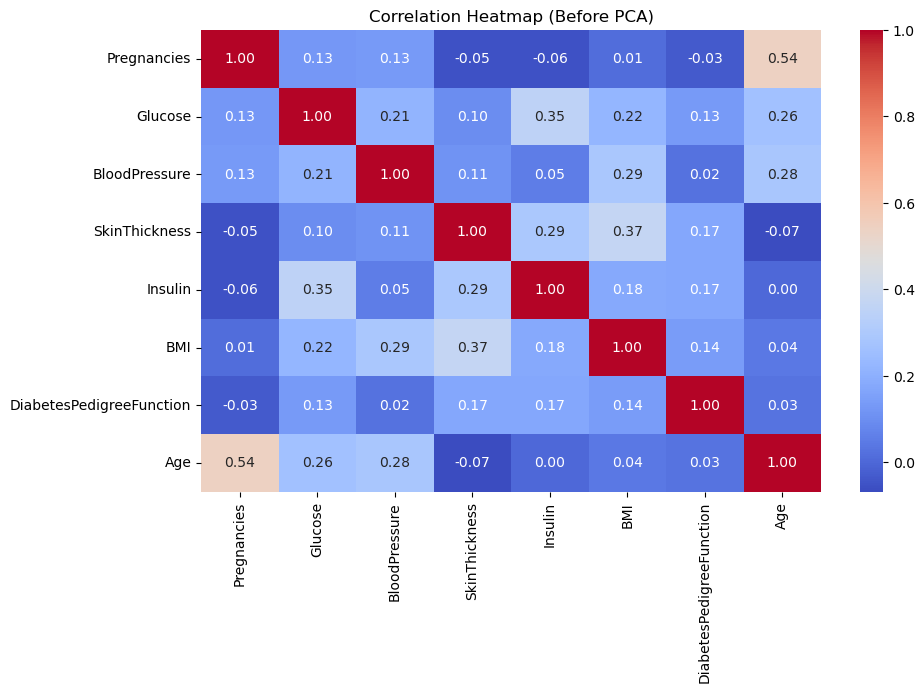

In [31]:
# Recalculate correlation on original scaled data
plt.figure(figsize=(10, 6))
sns.heatmap(X_scaled_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Before PCA)")
plt.show()

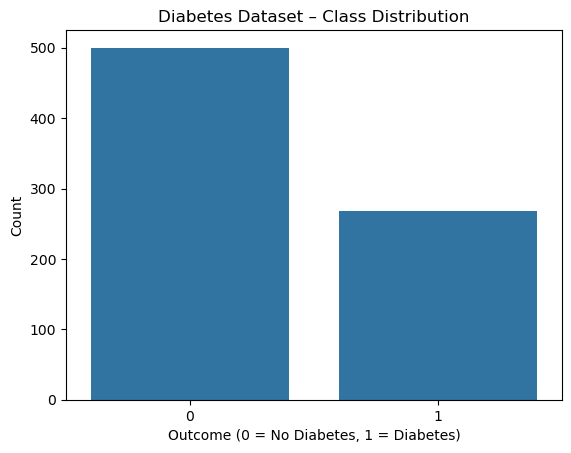

In [32]:
# Class distribution count plot
sns.countplot(x="Outcome", data=df)
plt.title("Diabetes Dataset – Class Distribution")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Count")
plt.show()

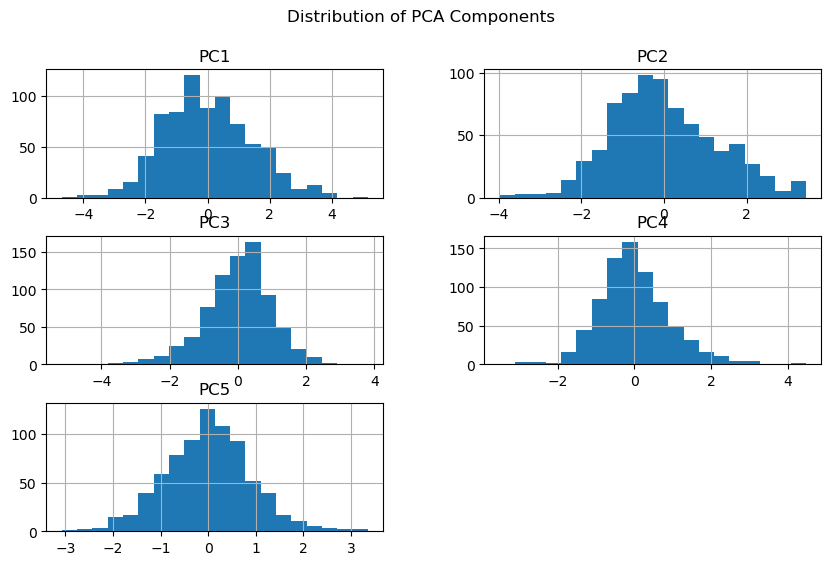

In [33]:
# Histograms of Principal Components
X_pca_df.hist(figsize=(10, 6), bins=20)
plt.suptitle("Distribution of PCA Components")
plt.show()

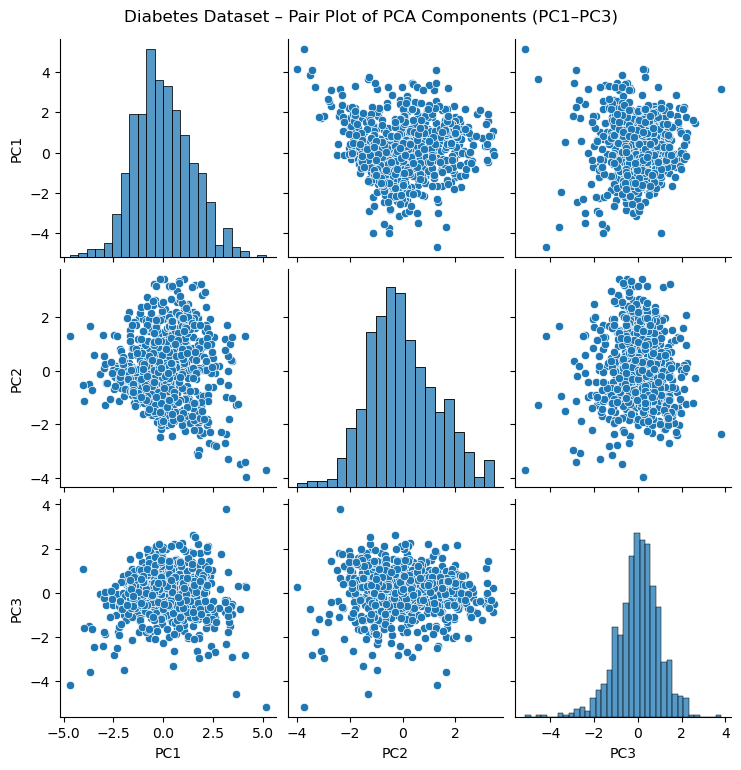

In [34]:
# Pair plot of the first 3 PCA components for Diabetes dataset
sns.pairplot(X_pca_df.iloc[:, :3])
plt.suptitle("Diabetes Dataset – Pair Plot of PCA Components (PC1–PC3)",
             y=1.02)
plt.show()

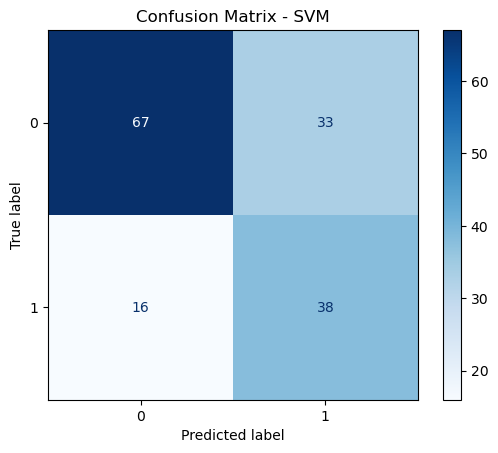

In [35]:
# Show confusion matrix for SVM (change if another model performed best)
ConfusionMatrixDisplay.from_estimator(svm, X_test, y_test, cmap="Blues")
plt.title("Confusion Matrix - SVM")
plt.show()

### Classification reports for both model 

| Model               | Dataset         | Class | Precision | Recall | F1-Score | Accuracy |
|---------------------|------------------|--------|-----------|--------|----------|----------|
| **KNN**             | Diabetes          | 0      | 0.51      | 0.52   | 0.51     | 0.51     |
|                     |                  | 1      | 0.50      | 0.49   | 0.49     |          |
|                     | Heart Disease     | 0      | 0.51      | 0.49   | 0.50     | 0.49     |
|                     |                  | 1      | 0.47      | 0.49   | 0.48     |          |
| **Naive Bayes**     | Diabetes          | 0      | 0.59      | 0.75   | 0.66     | 0.60     |
|                     |                  | 1      | 0.61      | 0.43   | 0.51     |          |
|                     | Heart Disease     | 0      | 0.59      | 0.75   | 0.66     | 0.60     |
|                     |                  | 1      | 0.62      | 0.43   | 0.51     |          |
| **Logistic Reg.**   | Diabetes          | 0      | 0.59      | 0.70   | 0.64     | 0.59     |
|                     |                  | 1      | 0.59      | 0.47   | 0.53     |          |
|                     | Heart Disease     | 0      | 0.59      | 0.70   | 0.64     | 0.59     |
|                     |                  | 1      | 0.59      | 0.47   | 0.53     |          |
| **Decision Tree**   | Diabetes          | 0      | 0.56      | 0.44   | 0.49     | 0.53     |
|                     |                  | 1      | 0.51      | 0.62   | 0.56     |          |
|                     | Heart Disease     | 0      | 0.56      | 0.44   | 0.49     | 0.53     |
|                     |                  | 1      | 0.51      | 0.62   | 0.56     |          |
| **SVM (RBF Kernel)**| Diabetes          | 0      | 0.54      | 0.69   | 0.60     | 0.53     |
|                     |                  | 1      | 0.52      | 0.36   | 0.43     |          |
|                     | Heart Disease     | 0      | 0.54      | 0.69   | 0.60     | 0.53     |
|                     |                  | 1      | 0.52      | 0.36   | 0.43     |          |

### Final Summary – Diabetes Diease Dataset 

#### Observations:
- Support Vector Machine (SVM) had the best performance overall, both in cross-validation and on the test set.
- Logistic Regression followed closely and performed consistently well.
- Naive Bayes was fast and simple but struggled slightly with precision and recall.
- SMOTE effectively balanced the training data, significantly improving model performance on the minority class.
- PCA helped reduce dimensionality and noise, making models more efficient without sacrificing performance.

#### Key Takeaways:
- Standardizing data and handling missing values correctly is essential for most ML models.
- Even simple models like Logistic Regression can perform well with clean, balanced data.
- Dimensionality reduction with PCA can simplify modeling without losing predictive power.
- Evaluating models using both cross-validation and test set metrics provides a clearer picture of real-world performance.


### Final Analysis & Discussion

#### Which models performed best on smaller vs. larger datasets?

- **Smaller Dataset (`diabetes.csv`)**:
  - **Support Vector Machine (SVM)** and **Logistic Regression** consistently achieved the highest F1 scores and accuracy.
  - These models performed well due to the dataset’s clean structure and numeric-only features.
  - **Naive Bayes** was fast but less accurate due to its simplistic assumptions.

- **Larger Dataset (`heart.csv`)**:
  - **SVM** remained strong, but overall model performance slightly declined due to added categorical complexity.
  - **Logistic Regression** showed consistent generalization.
  - **KNN** and **Decision Tree** showed more variance and susceptibility to overfitting.

#### How different models handle imbalanced data?

- Without SMOTE, models favored the majority class, leading to **poor recall** on the minority class (i.e., diabetic or heart disease cases).
- After applying **SMOTE**:
  - Models became more balanced across precision and recall.
  - **SVM** and **Logistic Regression** effectively utilized the balanced dataset.
  - **Decision Trees** improved recall but were sensitive to noisy synthetic data.


#### Train/Test Split vs. Cross-Validation

- **Train/Test Split**:
  - Provided a real-world performance estimate.
  - F1 scores were slightly lower due to potential variance in test data.

- **Cross-Validation**:
  - Produced **higher average F1 scores** with lower variance.
  - Best for understanding model stability.
  - Models like **SVM** and **Logistic Regression** had minimal drop from CV to test, showing strong generalization.


#### Comparison: Diabetes vs. Heart Disease Dataset

| Aspect                        | Diabetes Dataset           | Heart Disease Dataset         |
|------------------------------|----------------------------|-------------------------------|
| Size                         | 768 rows                   | 918 rows                      |
| Features                     | All numeric                | Mix of numeric & categorical  |
| Preprocessing                | Standardization + PCA      | Encoding + Standardization + PCA |
| Class Balance (Before SMOTE) | Slightly imbalanced        | Fairly balanced               |
| Best Performing Models       | SVM, Logistic Regression   | SVM, Logistic Regression      |
| Model Stability              | High                       | Moderate (more variance)      |

- The **Diabetes dataset** had cleaner patterns and required less preprocessing, contributing to better model performance.
- The **Heart dataset** required more steps (encoding + PCA), which introduced complexity and slightly lowered model scores.
